# **Estandarización iLOD - Test 200 pgmL matriz de café verde Sciex 7500+**




## **Análisis de repetibilidad instrumental**

# **1. Introducción**

# **2. Metodología de trabajo**

SAS Institute defines data mining as the process of Sampling, Exploring, Modifying, Modeling, and Assessing (SEMMA) large amounts of data to uncover previously unknown patterns which can be used as a business advantage. The data mining process is applicable across a variety of industries and provides methodologies for such diverse business problems as fraud detection, householding, customer retention and attrition, database marketing, market segmentation, risk analysis, affinity analysis, customer satisfaction, bankruptcy prediction, and portfolio analysis.

Enterprise Miner software is an integrated product that provides an end-to-end business solution for data mining.
A graphical user interface (GUI) provides a user-friendly front end to the SEMMA data mining process:

*   Sample the data by creating one or more data tables. The samples should be large enough to contain the significant information, yet small enough to process.

*   Explore the data by searching for anticipated relationships, unanticipated trends, and anomalies in order to gain understanding and ideas.

*   Modify the data by creating, selecting, and transforming the variables to focus the model selection process.

*   Model the data by using the analytical tools to search for a combination of the data that reliably predicts a desired outcome.
Assess the data by evaluating the usefulness and reliability of the findings from the data mining process.

# **0. Cargue de librerías**

En esta sección del Script se cargan todas las librerías necesarias para el análisis de los datos

In [34]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
# En este chunk dejamos totas las librerías que vamos a necesitar. Recomiendo siempre reutilizar este al comenzar un nuevo trabajo.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Numpy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

Numpy version: 2.0.2
Pandas version: 2.2.2
Seaborn version: 0.13.2


## **2.1 Sampling**

Se realiza lectura de los datos y se toma una fracción de los mismos para análisis.

### **2.1.1 Lectura de datos**

In [3]:
#Cargar el archivo
# Asegúrate de ajustar el separador ('\t' o ',' dependiendo del formato real)
df = pd.read_csv("iLOD-Results-Gaussian1-200pgml-matriz_cafe_verde.txt", sep="\t")

In [4]:
#Vista general de la base de datos
print(df.head())

   Index    Sample Name Sample Type          Component Name Component Type  \
0      1  Nivel-200pgmL    Standard  3 HYDROXY CARBOFURAN-1    Quantifiers   
1      2  Nivel-200pgmL    Standard  3 HYDROXY CARBOFURAN-2     Qualifiers   
2      3  Nivel-200pgmL    Standard         ABAMECTIN B1a-1    Quantifiers   
3      4  Nivel-200pgmL    Standard         ABAMECTIN B1a-2     Qualifiers   
4      5  Nivel-200pgmL    Standard              ACEPHATE-1    Quantifiers   

   Component Group Name  Actual Concentration  Expected RT           Area  \
0  3 HYDROXY CARBOFURAN                   500         3.34  204078.944125   
1  3 HYDROXY CARBOFURAN                   500         3.34  142718.186616   
2         ABAMECTIN B1a                   500        11.81    2337.458831   
3         ABAMECTIN B1a                   500        11.81    3143.777736   
4              ACEPHATE                   500         2.02  303354.317551   

   Retention Time  Retention Time Delta (min)  Signal / Noise  Used 

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Index                       2340 non-null   int64  
 1   Sample Name                 2340 non-null   object 
 2   Sample Type                 2340 non-null   object 
 3   Component Name              2340 non-null   object 
 4   Component Type              2340 non-null   object 
 5   Component Group Name        2340 non-null   object 
 6   Actual Concentration        2340 non-null   int64  
 7   Expected RT                 2340 non-null   float64
 8   Area                        2324 non-null   float64
 9   Retention Time              2324 non-null   float64
 10  Retention Time Delta (min)  2324 non-null   float64
 11  Signal / Noise              2324 non-null   float64
 12  Used                        2340 non-null   bool   
 13  Calculated Concentration    2324 

### **2.1.2 Muestreo de los datos**

In [6]:
# Seleccionar las columnas relevantes
cols = ["Component Group Name", "Component Type", "Area", "Retention Time"]
df_Sampled = df[cols]

In [7]:
# Asegurarse de que los datos numéricos estén correctamente convertidos
df_Sampled["Area"] = pd.to_numeric(df_Sampled["Area"], errors="coerce")
df_Sampled["Retention Time"] = pd.to_numeric(df_Sampled["Retention Time"], errors="coerce")

/tmp/ipython-input-3035842048.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Sampled["Area"] = pd.to_numeric(df_Sampled["Area"], errors="coerce")
/tmp/ipython-input-3035842048.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Sampled["Retention Time"] = pd.to_numeric(df_Sampled["Retention Time"], errors="coerce")


In [8]:
print(df_Sampled.head())

   Component Group Name Component Type           Area  Retention Time
0  3 HYDROXY CARBOFURAN    Quantifiers  204078.944125        3.339497
1  3 HYDROXY CARBOFURAN     Qualifiers  142718.186616        3.342475
2         ABAMECTIN B1a    Quantifiers    2337.458831       11.805006
3         ABAMECTIN B1a     Qualifiers    3143.777736       11.825361
4              ACEPHATE    Quantifiers  303354.317551        2.026142


In [9]:
print(df_Sampled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Component Group Name  2340 non-null   object 
 1   Component Type        2340 non-null   object 
 2   Area                  2324 non-null   float64
 3   Retention Time        2324 non-null   float64
dtypes: float64(2), object(2)
memory usage: 73.3+ KB
None


## **2.2 Exploración de datos**

### **2.2.1 Limpieza de base de datos**

En esta sección se revisa la base de datos para la busqueda de datos faltantes, duplicados y errores de transcripción.

**Busqueda de datos faltantes**




In [10]:
#Este código suma el total de valores faltantes por columna y los presenta
df_Sampled.isna().sum()

,0
Component Group Name,0
Component Type,0
Area,16
Retention Time,16


**Eliminación de datos faltantes**



In [11]:
df_Sampled.dropna(inplace=True)
df_Sampled.isna().sum()

/tmp/ipython-input-3147249471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Sampled.dropna(inplace=True)


,0
Component Group Name,0
Component Type,0
Area,0
Retention Time,0


**Busqueda de duplicados**

In [12]:
#Aquí se realiza la suma total de los datos duplicados
df_Sampled.duplicated().sum()

np.int64(0)

In [13]:
df_Sampled.drop_duplicates(inplace=True)
df_Sampled.duplicated().sum()

/tmp/ipython-input-1519474588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Sampled.drop_duplicates(inplace=True)


np.int64(0)

## **2.3 Modificación de datos**



### **2.3.1 Busqueda de datos anómalos**

In [14]:
# -----------------------
# 🔟 Detección de datos anómalos (outliers)
# -----------------------

def detectar_outliers(grupo, columna):
    q1 = grupo[columna].quantile(0.25)
    q3 = grupo[columna].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return grupo[(grupo[columna] < lim_inf) | (grupo[columna] > lim_sup)]

# Detectar outliers en ambas variables
outliers_area = df_Sampled.groupby("Component Group Name", group_keys=False).apply(detectar_outliers, "Area")
outliers_rt = df_Sampled.groupby("Component Group Name", group_keys=False).apply(detectar_outliers, "Retention Time")

# Etiquetar el tipo de outlier
outliers_area["Tipo"] = "Área"
outliers_rt["Tipo"] = "Tiempo de Retención"

# Unir ambos
outliers_total = pd.concat([outliers_area, outliers_rt]).reset_index(drop=True)

# Resumen de cantidad de outliers por grupo
resumen_outliers = (
    outliers_total.groupby(["Component Group Name", "Tipo"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
resumen_outliers["Total Outliers"] = resumen_outliers.sum(axis=1, numeric_only=True)

print(resumen_outliers)

/tmp/ipython-input-4105352263.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_area = df_Sampled.groupby("Component Group Name", group_keys=False).apply(detectar_outliers, "Area")


Tipo Component Group Name  Tiempo de Retención  Área  Total Outliers
0                ALDICARB                    1     0               1
1        ALDICARB SULFONE                    3     0               3
2      ALDICARB SULFOXIDE                    1     0               1
3                ATRAZINE                    2     0               2
4                 BENOMYL                    3     1               4
..                    ...                  ...   ...             ...
87         TERBUTHYLAZINE                    1     0               1
88            THIACLOPRID                    1     0               1
89       TOLCLOFOS METHYL                    2     0               2
90             TRIAZOPHOS                    1     0               1
91            TRIFLUMURON                    1     0               1

[92 rows x 4 columns]


/tmp/ipython-input-4105352263.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_rt = df_Sampled.groupby("Component Group Name", group_keys=False).apply(detectar_outliers, "Retention Time")


In [15]:
# Guardar los resultados
outliers_total.to_excel("Datos_outliers_detalle.xlsx", index=False)

# Save the first sheet to the Excel file, creating the file if it doesn't exist
with pd.ExcelWriter("Resumen_estadistico_por_componente.xlsx", mode="w", engine="openpyxl") as writer:
    resumen_outliers.to_excel(writer, sheet_name="Outliers por Grupo", index=False)

# Append the second sheet to the existing Excel file
with pd.ExcelWriter("Resumen_estadistico_por_componente.xlsx", mode="a", engine="openpyxl") as writer:
    outliers_total.to_excel(writer, sheet_name="Outlier Details", index=False)

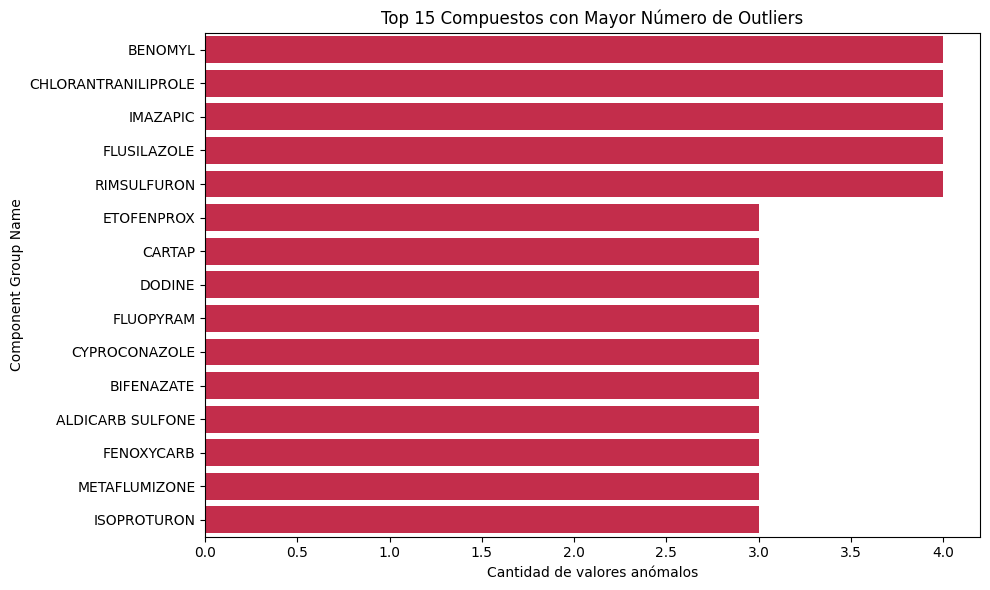

In [16]:
#Visualización de grupos con más outliers

top_outliers = resumen_outliers.sort_values("Total Outliers", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_outliers, x="Total Outliers", y="Component Group Name", color="crimson")
plt.title("Top 15 Compuestos con Mayor Número de Outliers")
plt.xlabel("Cantidad de valores anómalos")
plt.ylabel("Component Group Name")
plt.tight_layout()


### **2.3.2 Eliminación de datos anómalos**

In [17]:
# Eliminación de outliers por grupo (método IQR)

def filtrar_outliers(grupo, columna):
    q1 = grupo[columna].quantile(0.25)
    q3 = grupo[columna].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return grupo[(grupo[columna] >= lim_inf) & (grupo[columna] <= lim_sup)]

# Filtrar datos válidos en ambas columnas
df_filtered = (
    df_Sampled.groupby("Component Group Name", group_keys=False)
      .apply(filtrar_outliers, "Area")
      .groupby("Component Group Name", group_keys=False)
      .apply(filtrar_outliers, "Retention Time")
)

# Verificar cantidad de datos eliminados
n_original = len(df)
n_filtrado = len(df_filtered)
print(f"✅ Datos filtrados por IQR completado.")
print(f"   Registros originales: {n_original}")
print(f"   Registros después de limpiar: {n_filtrado}")
print(f"   Registros eliminados: {n_original - n_filtrado}")

# Guardar base de datos limpia
print(df_filtered.head())
print(df_filtered.info())


/tmp/ipython-input-3477491267.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(filtrar_outliers, "Area")


✅ Datos filtrados por IQR completado.
   Registros originales: 2340
   Registros después de limpiar: 2169
   Registros eliminados: 171
     Component Group Name Component Type           Area  Retention Time
0    3 HYDROXY CARBOFURAN    Quantifiers  204078.944125        3.339497
1    3 HYDROXY CARBOFURAN     Qualifiers  142718.186616        3.342475
468  3 HYDROXY CARBOFURAN    Quantifiers  236550.899536        3.332220
469  3 HYDROXY CARBOFURAN     Qualifiers  113746.720039        3.333877
936  3 HYDROXY CARBOFURAN    Quantifiers  226773.223402        3.328749
<class 'pandas.core.frame.DataFrame'>
Index: 2169 entries, 0 to 2339
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Component Group Name  2169 non-null   object 
 1   Component Type        2169 non-null   object 
 2   Area                  2169 non-null   float64
 3   Retention Time        2169 non-null   float64
dtypes: float64(2), object

/tmp/ipython-input-3477491267.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(filtrar_outliers, "Retention Time")


## **2.4 Exploración**

### **2.4.1 Análisis gráfico exploratorio**

Text(0.5, 0, 'Área')

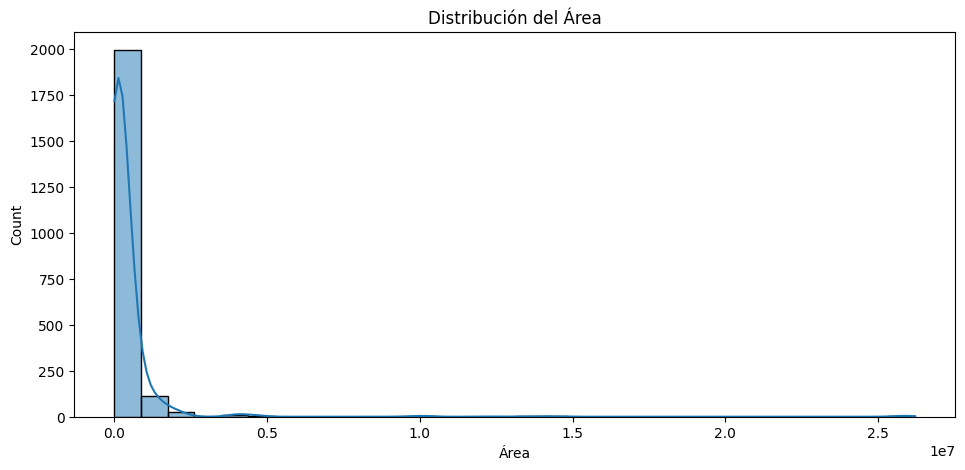

In [18]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
sns.histplot(df_filtered["Area"], kde=True, bins=30)
plt.title("Distribución del Área")
plt.xlabel("Área")

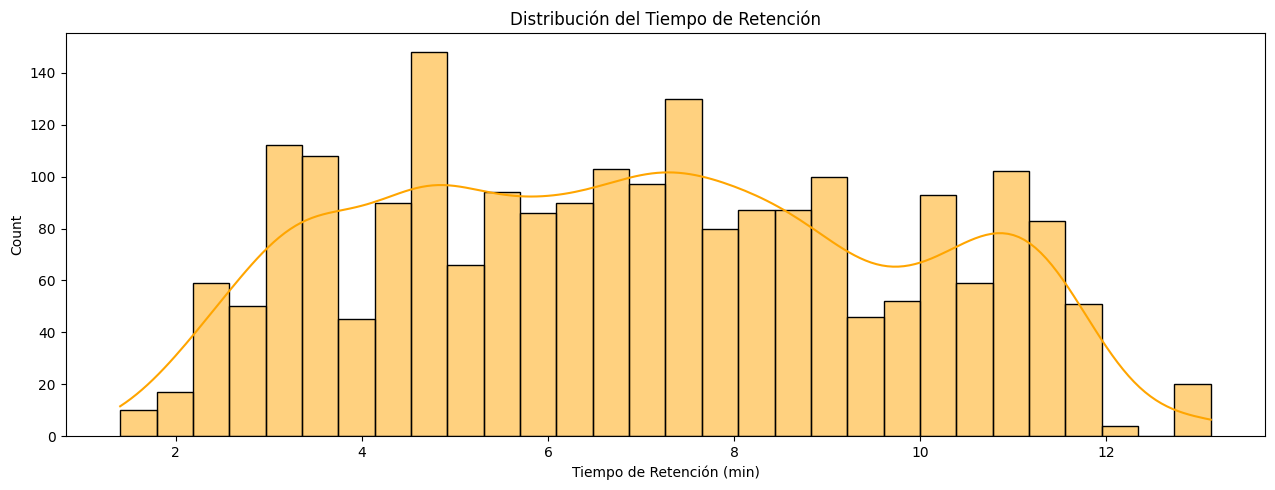

In [19]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,2)
sns.histplot(df_filtered["Retention Time"], kde=True, bins=30, color="orange")
plt.title("Distribución del Tiempo de Retención")
plt.xlabel("Tiempo de Retención (min)")
plt.tight_layout()

### **2.2.4 Estadísticos de resumen**

In [20]:
# 3️⃣ Asegurarse de que los datos numéricos estén correctamente convertidos
df_filtered["Area"] = pd.to_numeric(df_filtered["Area"], errors="coerce")
df_filtered["Retention Time"] = pd.to_numeric(df_filtered["Retention Time"], errors="coerce")

In [21]:
print(df_filtered.head())

     Component Group Name Component Type           Area  Retention Time
0    3 HYDROXY CARBOFURAN    Quantifiers  204078.944125        3.339497
1    3 HYDROXY CARBOFURAN     Qualifiers  142718.186616        3.342475
468  3 HYDROXY CARBOFURAN    Quantifiers  236550.899536        3.332220
469  3 HYDROXY CARBOFURAN     Qualifiers  113746.720039        3.333877
936  3 HYDROXY CARBOFURAN    Quantifiers  226773.223402        3.328749


In [22]:
# -----------------------
# 4️⃣ Agrupar por "Component Type" y "Component Group Name" y calcular estadísticas descriptivas
# -----------------------

stats = df.groupby(["Component Type", "Component Group Name"]).agg({
    "Area": ["count", "mean", "std", "min", "max"],
    "Retention Time": ["mean", "std", "min", "max"]
})

# -----------------------
# 5️⃣ Calcular el %CV (coeficiente de variación)
# -----------------------
stats[("Area", "%CV")] = (stats[("Area", "std")] / stats[("Area", "mean")]) * 100
stats[("Retention Time", "%CV")] = (stats[("Retention Time", "std")] / stats[("Retention Time", "mean")]) * 100

# -----------------------
# 6️⃣ Reorganizar columnas para mejor visualización
# -----------------------
stats = stats[
    [
        ("Area", "count"), ("Area", "mean"), ("Area", "std"), ("Area", "%CV"),
        ("Retention Time", "mean"), ("Retention Time", "std"), ("Retention Time", "%CV")
    ]
]

# -----------------------
# 7️⃣ Exportar resultados a Excel
# -----------------------
# Aplanar nombres de columnas antes de exportar (evita errores con MultiIndex)
stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
stats = stats.reset_index()

# Guardar en Excel
stats.to_excel("Resumen_estadistico_por_tipo_y_componente.xlsx", index=False)

print("✅ Análisis completado con éxito.")
print("📄 Archivo generado: 'Resumen_estadistico_por_tipo_y_componente.xlsx'")

✅ Análisis completado con éxito.
📄 Archivo generado: 'Resumen_estadistico_por_tipo_y_componente.xlsx'


In [23]:
print(stats.head())

  Component Type  Component Group Name  Area_count      Area_mean  \
0     Qualifiers  3 HYDROXY CARBOFURAN           5  125894.836515   
1     Qualifiers         ABAMECTIN B1a           5    1971.110493   
2     Qualifiers              ACEPHATE           5   42924.249665   
3     Qualifiers           ACEQUINOCYL           5   17675.135144   
4     Qualifiers           ACETAMIPRID           5   15573.731458   

       Area_std   Area_%CV  Retention Time_mean  Retention Time_std  \
0  26036.162910  20.680882             3.338748            0.009328   
1    788.157683  39.985464            11.890967            0.107202   
2   4530.069115  10.553636             2.036405            0.008277   
3    860.159000   4.866492            12.893350            0.006803   
4   2695.854065  17.310264             3.353004            0.008930   

   Retention Time_%CV  
0            0.279381  
1            0.901545  
2            0.406452  
3            0.052763  
4            0.266334  


## **2.5 Modelamiento**

### **2.5.1 Graficos de resumen %CV**

In [24]:
print(stats.head())

  Component Type  Component Group Name  Area_count      Area_mean  \
0     Qualifiers  3 HYDROXY CARBOFURAN           5  125894.836515   
1     Qualifiers         ABAMECTIN B1a           5    1971.110493   
2     Qualifiers              ACEPHATE           5   42924.249665   
3     Qualifiers           ACEQUINOCYL           5   17675.135144   
4     Qualifiers           ACETAMIPRID           5   15573.731458   

       Area_std   Area_%CV  Retention Time_mean  Retention Time_std  \
0  26036.162910  20.680882             3.338748            0.009328   
1    788.157683  39.985464            11.890967            0.107202   
2   4530.069115  10.553636             2.036405            0.008277   
3    860.159000   4.866492            12.893350            0.006803   
4   2695.854065  17.310264             3.353004            0.008930   

   Retention Time_%CV  
0            0.279381  
1            0.901545  
2            0.406452  
3            0.052763  
4            0.266334  


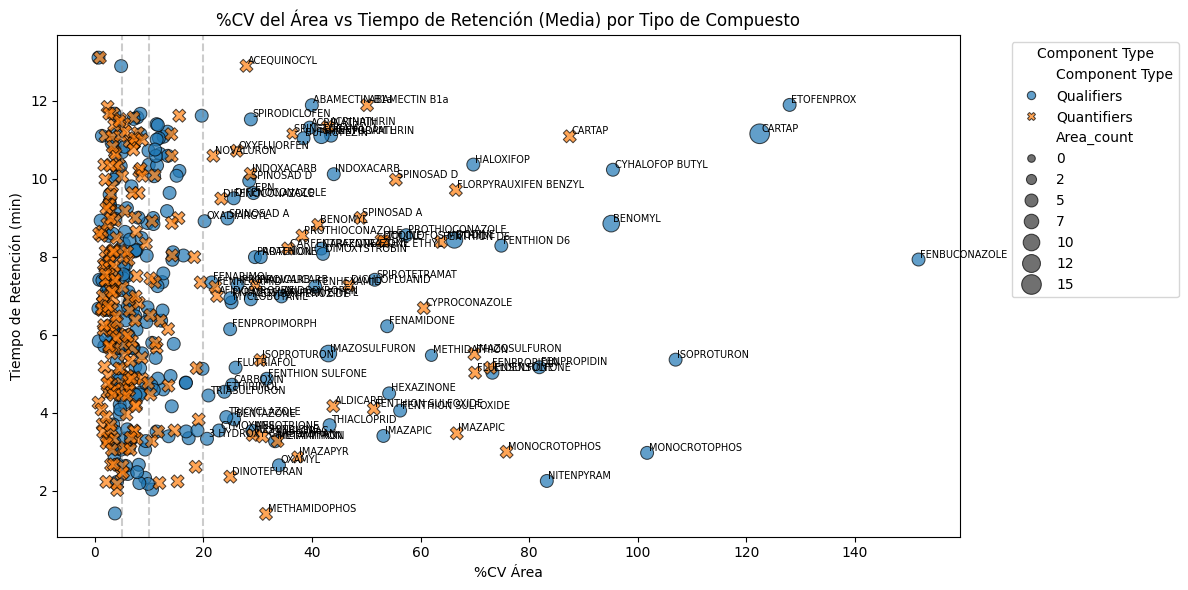

In [25]:
# -----------------------
# 🎯 Scatter plot %CV Área vs Tiempo de Retención (media), separado por Compound Type (en color)
# -----------------------

# Aplanar nombres de columnas si aún no se ha hecho
if isinstance(stats.columns, pd.MultiIndex):
    stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
stats_reset = stats.reset_index()

# Crear categorías de variabilidad
def clasificar_cv(valor):
    if valor > 20:
        return "Alta (>20%)"
    elif valor > 10:
        return "Media (10-20%)"
    elif valor > 5:
        return "Baja (5-10%)"
    else:
        return "Muy baja (<5%)"

# Clasificar según %CV del área
stats_reset["Categoria_Area"] = stats_reset["Area_%CV"].apply(clasificar_cv)

# Crear gráfico combinado
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=stats_reset,
    x="Area_%CV",
    y="Retention Time_mean",
    hue="Component Type",           # ← separa por tipo
    style="Component Type",         # ← diferente marcador
    size="Area_count",
    sizes=(30, 200),
    alpha=0.7,
    edgecolor="black"
)

# Etiquetar solo los compuestos con alta variabilidad
for _, row in stats_reset.iterrows():
    if row["Area_%CV"] > 20:
        plt.text(row["Area_%CV"] + 0.3, row["Retention Time_mean"] + 0.05,
                 row["Component Group Name"], fontsize=7)

# Líneas de referencia
plt.axvline(5, color="gray", linestyle="--", alpha=0.4)
plt.axvline(10, color="gray", linestyle="--", alpha=0.4)
plt.axvline(20, color="gray", linestyle="--", alpha=0.4)

plt.title("%CV del Área vs Tiempo de Retención (Media) por Tipo de Compuesto")
plt.xlabel("%CV Área")
plt.ylabel("Tiempo de Retención (min)")
plt.legend(title="Component Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


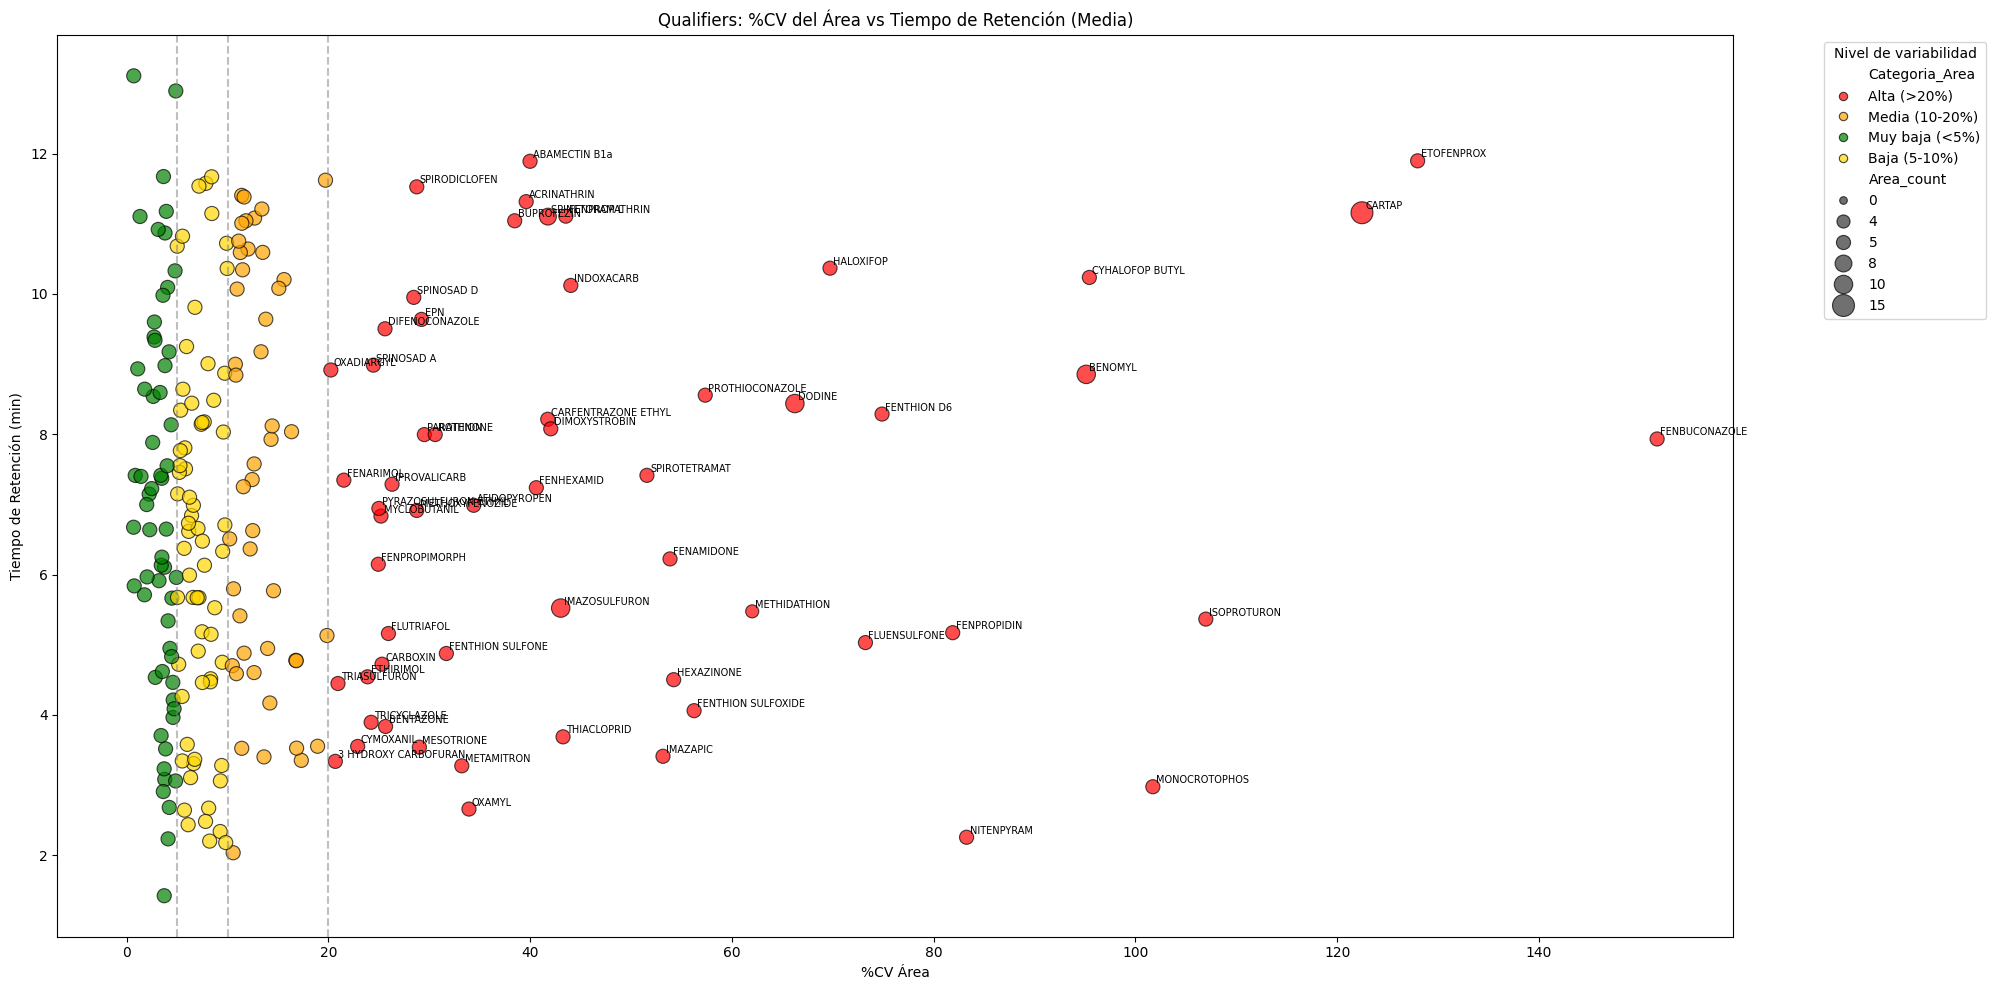

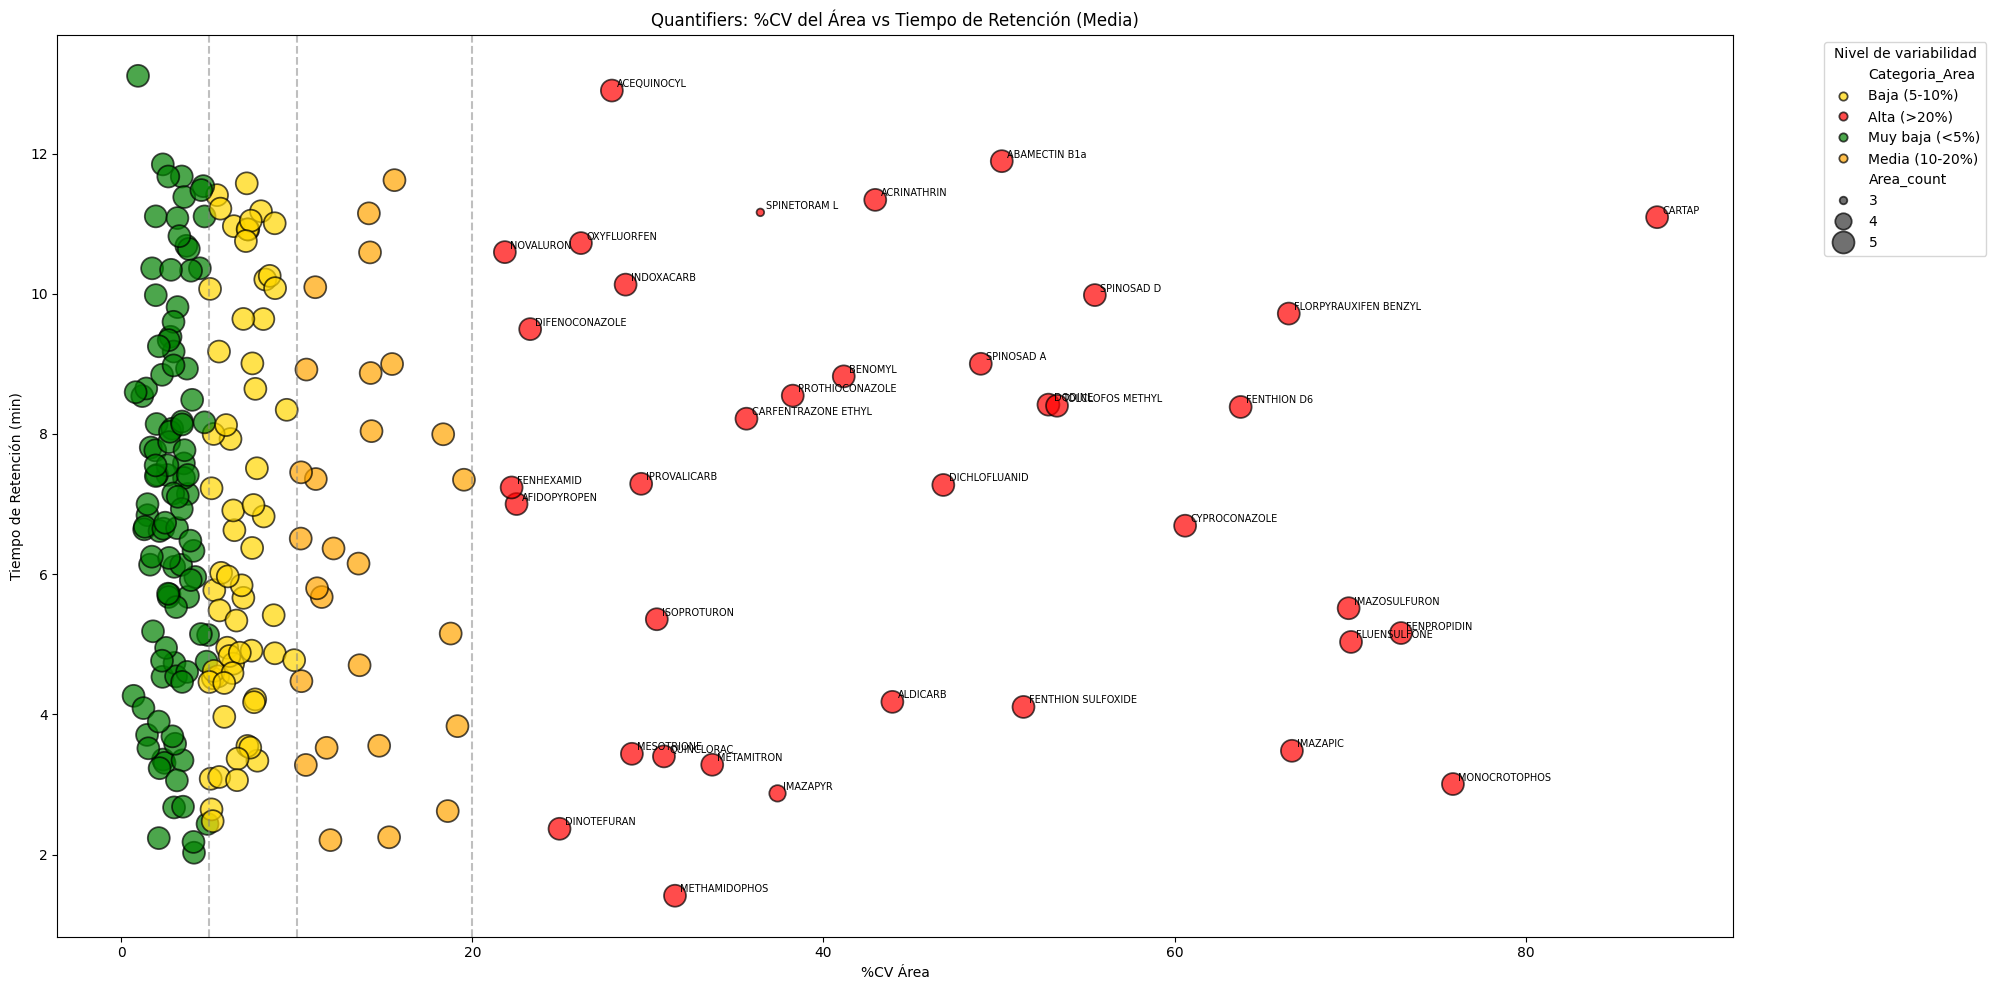

In [26]:
# -----------------------
# 📊 Scatter plots separados por Compound Type
# -----------------------

compound_types = stats_reset["Component Type"].unique()

for ctype in compound_types:
    subset = stats_reset[stats_reset["Component Type"] == ctype]

    plt.figure(figsize=(20,10))
    sns.scatterplot(
        data=subset,
        x="Area_%CV",
        y="Retention Time_mean",
        hue="Categoria_Area",
        palette={
            "Alta (>20%)": "red",
            "Media (10-20%)": "orange",
            "Baja (5-10%)": "gold",
            "Muy baja (<5%)": "green"
        },
        size="Area_count",
        sizes=(30, 250),
        alpha=0.7,
        edgecolor="black"
    )

    # Etiquetar los de alta variabilidad
    for _, row in subset.iterrows():
        if row["Area_%CV"] > 20:
            plt.text(row["Area_%CV"] + 0.3, row["Retention Time_mean"] + 0.05,
                     row["Component Group Name"], fontsize=7)

    plt.axvline(5, color="gray", linestyle="--", alpha=0.5)
    plt.axvline(10, color="gray", linestyle="--", alpha=0.5)
    plt.axvline(20, color="gray", linestyle="--", alpha=0.5)

    plt.title(f"{ctype}: %CV del Área vs Tiempo de Retención (Media)")
    plt.xlabel("%CV Área")
    plt.ylabel("Tiempo de Retención (min)")
    plt.legend(title="Nivel de variabilidad", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

In [27]:
print(stats.head())

  Component Type  Component Group Name  Area_count      Area_mean  \
0     Qualifiers  3 HYDROXY CARBOFURAN           5  125894.836515   
1     Qualifiers         ABAMECTIN B1a           5    1971.110493   
2     Qualifiers              ACEPHATE           5   42924.249665   
3     Qualifiers           ACEQUINOCYL           5   17675.135144   
4     Qualifiers           ACETAMIPRID           5   15573.731458   

       Area_std   Area_%CV  Retention Time_mean  Retention Time_std  \
0  26036.162910  20.680882             3.338748            0.009328   
1    788.157683  39.985464            11.890967            0.107202   
2   4530.069115  10.553636             2.036405            0.008277   
3    860.159000   4.866492            12.893350            0.006803   
4   2695.854065  17.310264             3.353004            0.008930   

   Retention Time_%CV  
0            0.279381  
1            0.901545  
2            0.406452  
3            0.052763  
4            0.266334  


In [28]:
# -----------------------
# 📊 Resumen detallado por Component Group Name y Compound Type
# -----------------------

# Seleccionar solo las columnas relevantes
cols_resumen = [
    "Component Type", "Component Group Name",
    "Area_count", "Area_mean", "Area_std", "Area_%CV",
    "Retention_Time_mean", "Retention_Time_std", "Retention_Time_%CV"
]

# Verificar que todas las columnas existan
cols_resumen = [c for c in cols_resumen if c in stats_reset.columns]

df_resumen = stats_reset[cols_resumen].copy()

# Redondear valores numéricos
df_resumen = df_resumen.round(3)

# Ordenar por nombre del componente y tipo
df_resumen = df_resumen.sort_values(by=["Component Group Name", "Component Type"])

# Mostrar parte del resumen en consola
print("\n📘 Resumen por Componente y Tipo:")
print(df_resumen.head(10))

# Guardar en Excel
with pd.ExcelWriter("Resumen_estadistico_por_tipo_y_componente.xlsx",
                    mode="a", engine="openpyxl", if_sheet_exists="overlay") as writer:
    df_resumen.to_excel(writer, sheet_name="Resumen_Componente_Tipo", index=False)

print("✅ Hoja 'Resumen_Componente_Tipo' añadida al archivo 'Resumen_estadistico_por_tipo_y_componente.xlsx'")



📘 Resumen por Componente y Tipo:
    Component Type  Component Group Name  Area_count   Area_mean   Area_std  \
0       Qualifiers  3 HYDROXY CARBOFURAN           5  125894.837  26036.163   
230    Quantifiers  3 HYDROXY CARBOFURAN           5  224057.504  17378.852   
1       Qualifiers         ABAMECTIN B1a           5    1971.110    788.158   
231    Quantifiers         ABAMECTIN B1a           5    1700.744    853.100   
2       Qualifiers              ACEPHATE           5   42924.250   4530.069   
232    Quantifiers              ACEPHATE           5  296283.185  12285.589   
3       Qualifiers           ACEQUINOCYL           5   17675.135    860.159   
233    Quantifiers           ACEQUINOCYL           5   20864.418   5831.533   
4       Qualifiers           ACETAMIPRID           5   15573.731   2695.854   
234    Quantifiers           ACETAMIPRID           5  486846.123  11617.418   

     Area_%CV  
0      20.681  
230     7.756  
1      39.985  
231    50.160  
2      10.554  


In [29]:
print(df_resumen.head())

    Component Type  Component Group Name  Area_count   Area_mean   Area_std  \
0       Qualifiers  3 HYDROXY CARBOFURAN           5  125894.837  26036.163   
230    Quantifiers  3 HYDROXY CARBOFURAN           5  224057.504  17378.852   
1       Qualifiers         ABAMECTIN B1a           5    1971.110    788.158   
231    Quantifiers         ABAMECTIN B1a           5    1700.744    853.100   
2       Qualifiers              ACEPHATE           5   42924.250   4530.069   

     Area_%CV  
0      20.681  
230     7.756  
1      39.985  
231    50.160  
2      10.554  


### **2.5.2 Resumen final %CV**

In [30]:
resumen_stat_final = pd.read_excel("Resumen_estadistico_por_tipo_y_componente.xlsx", sheet_name="Sheet1")
print(resumen_stat_final.head())

  Component Type  Component Group Name  Area_count      Area_mean  \
0     Qualifiers  3 HYDROXY CARBOFURAN           5  125894.836515   
1     Qualifiers         ABAMECTIN B1a           5    1971.110493   
2     Qualifiers              ACEPHATE           5   42924.249665   
3     Qualifiers           ACEQUINOCYL           5   17675.135144   
4     Qualifiers           ACETAMIPRID           5   15573.731458   

       Area_std   Area_%CV  Retention Time_mean  Retention Time_std  \
0  26036.162910  20.680882             3.338748            0.009328   
1    788.157683  39.985464            11.890967            0.107202   
2   4530.069115  10.553636             2.036405            0.008277   
3    860.159000   4.866492            12.893350            0.006803   
4   2695.854065  17.310264             3.353004            0.008930   

   Retention Time_%CV  
0            0.279381  
1            0.901545  
2            0.406452  
3            0.052763  
4            0.266334  


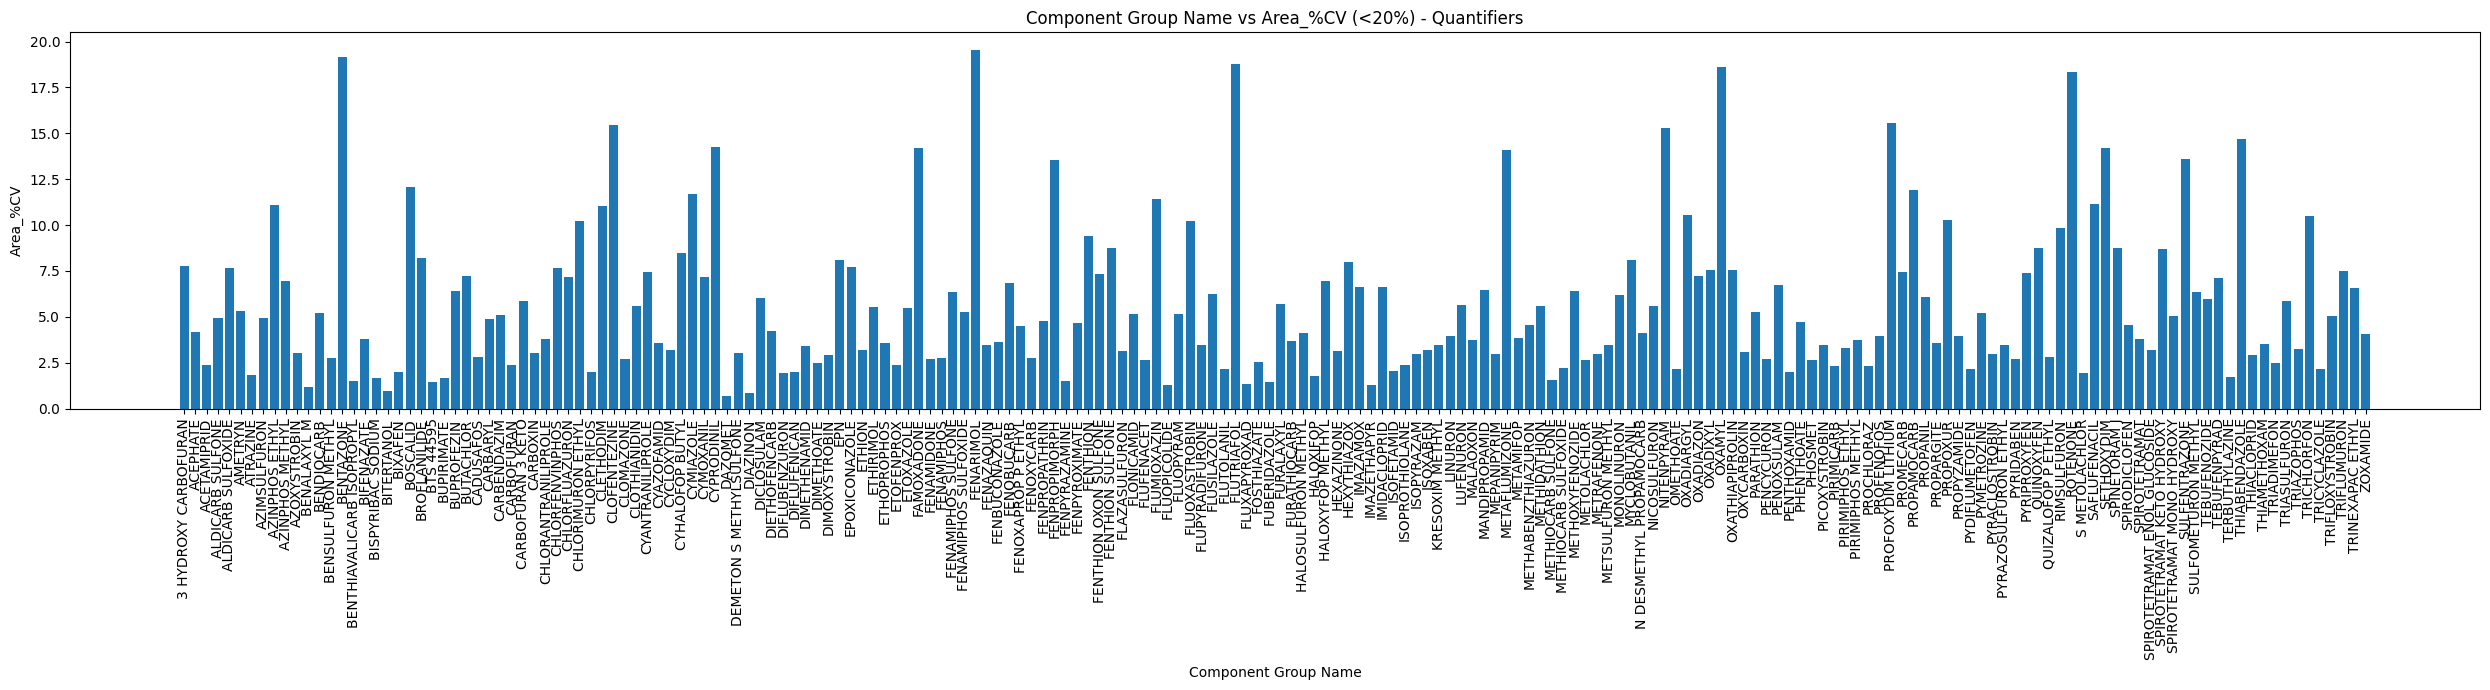

,Component Type,Component Group Name,Area_count,Area_mean,Area_std,Area_%CV,Retention Time_mean,Retention Time_std,Retention Time_%CV
230,Quantifiers,3 HYDROXY CARBOFURAN,5,2.240575e+05,17378.851838,7.756425,3.338676,0.008974,0.268780
232,Quantifiers,ACEPHATE,5,2.962832e+05,12285.588964,4.146570,2.025937,0.008630,0.425961
234,Quantifiers,ACETAMIPRID,5,4.868461e+05,11617.418036,2.386261,3.355195,0.007898,0.235384
238,Quantifiers,ALDICARB SULFONE,5,1.204137e+05,5921.208726,4.917387,2.436751,0.007445,0.305520
239,Quantifiers,ALDICARB SULFOXIDE,5,2.087828e+06,159406.045745,7.635018,4.213463,0.007053,0.167388


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar por Component Type = Quantifiers y Area_%CV < 20
resumen_stat_final_filtered = resumen_stat_final[(resumen_stat_final["Component Type"] == "Quantifiers") & (resumen_stat_final["Area_%CV"] < 20)]

# Crear gráfico de barras
plt.figure(figsize=(25, 7))
plt.bar(resumen_stat_final_filtered["Component Group Name"], resumen_stat_final_filtered["Area_%CV"])
plt.xticks(rotation=90)
plt.xlabel("Component Group Name")
plt.ylabel("Area_%CV")
plt.title("Component Group Name vs Area_%CV (<20%) - Quantifiers")
plt.tight_layout()
plt.show()

resumen_stat_final_filtered.head()


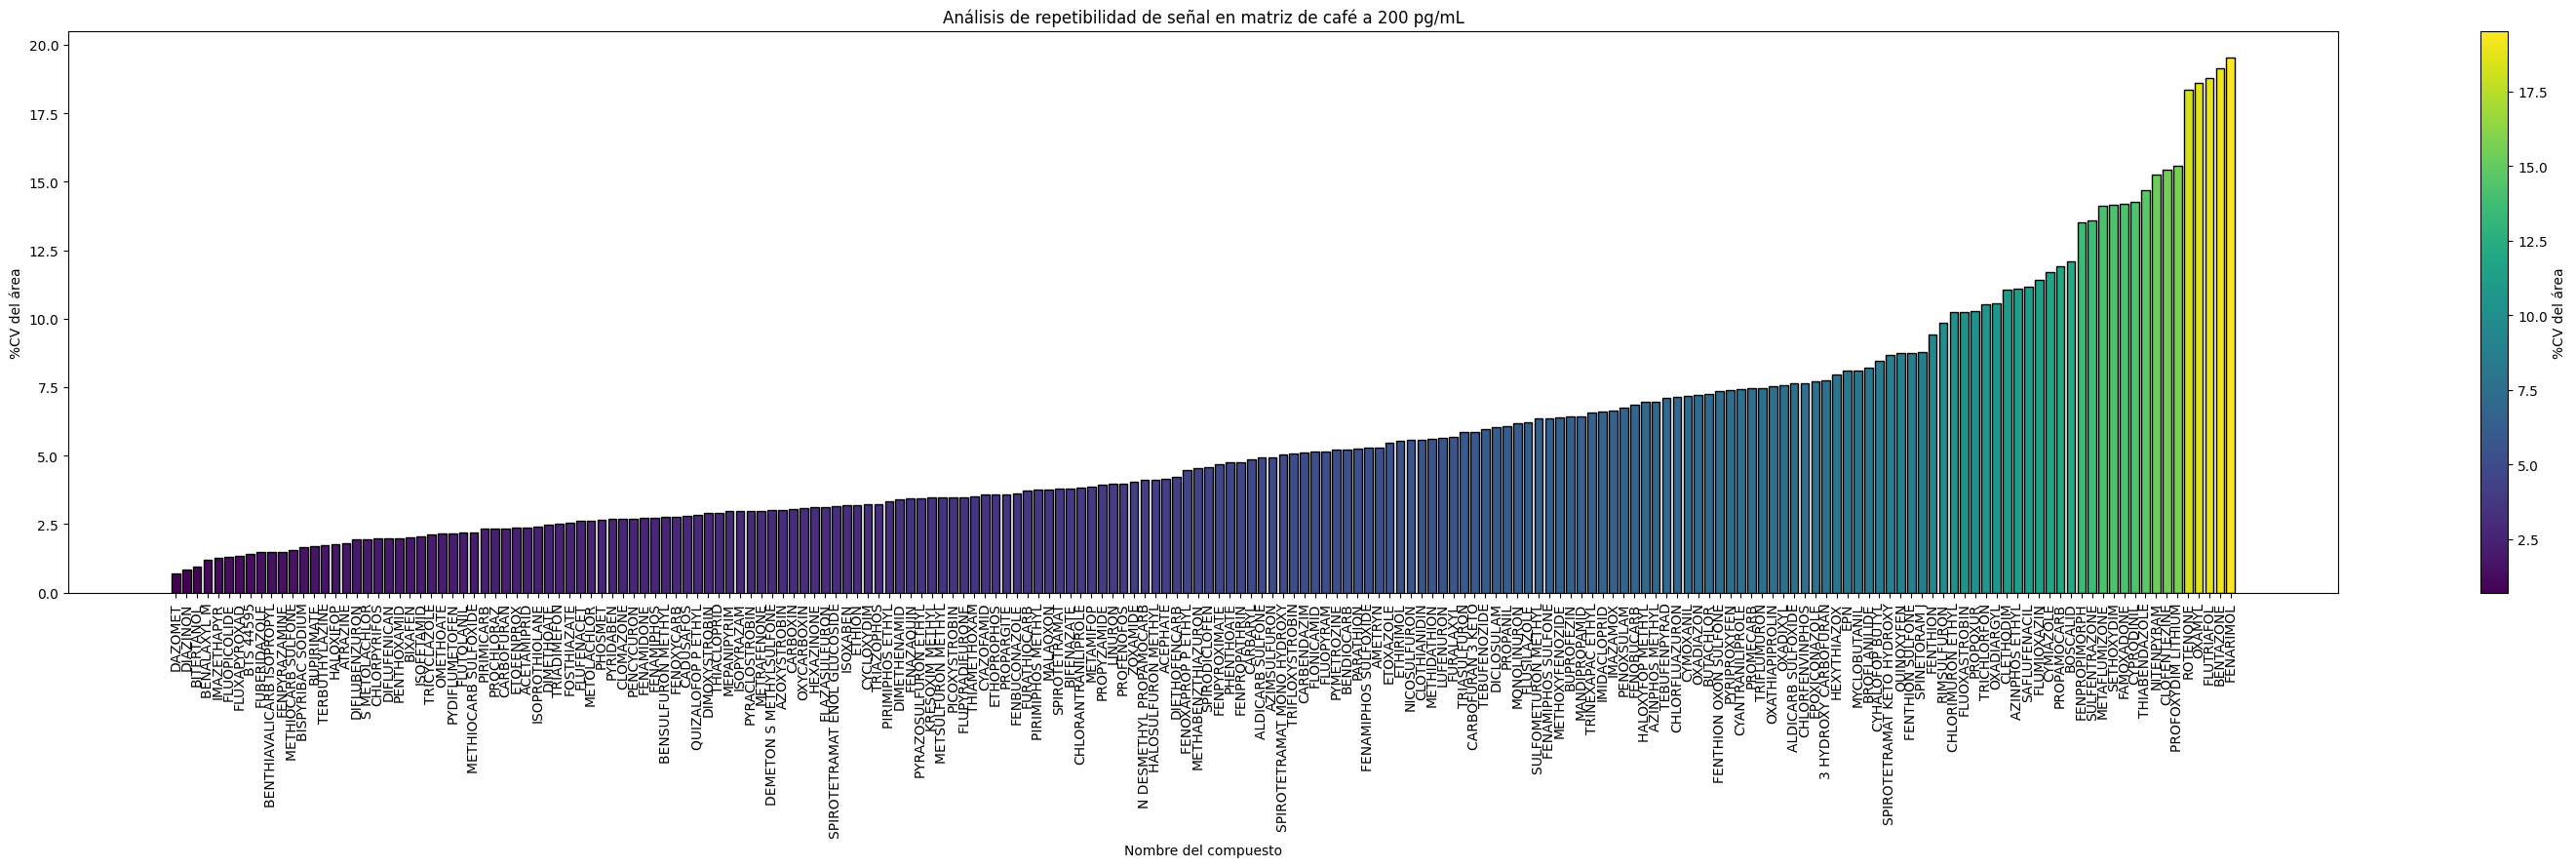

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenar por Area_%CV de menor a mayor
resumen_stat_final_sorted = resumen_stat_final_filtered.sort_values(by="Area_%CV", ascending=True)

# Normalizar los valores de %CV para asignarles colores según su magnitud
norm = plt.Normalize(resumen_stat_final_sorted["Area_%CV"].min(), resumen_stat_final_sorted["Area_%CV"].max())
colors = plt.cm.viridis(norm(resumen_stat_final_sorted["Area_%CV"]))  # Puedes cambiar viridis por coolwarm, plasma, etc.

# Crear gráfico de barras ordenado con degradado
plt.figure(figsize=(30, 9))
plt.bar(
    resumen_stat_final_sorted["Component Group Name"],
    resumen_stat_final_sorted["Area_%CV"],
    color=colors,
    edgecolor='black'
)
plt.xticks(rotation=90)
plt.xlabel("Nombre del compuesto")
plt.ylabel("%CV del área")
plt.title("Análisis de repetibilidad de señal en matriz de café a 200 pg/mL")

# Agregar barra de color como referencia visual
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca()) # Modified line: added ax=plt.gca()
cbar.set_label("%CV del área")

plt.tight_layout()
plt.show()

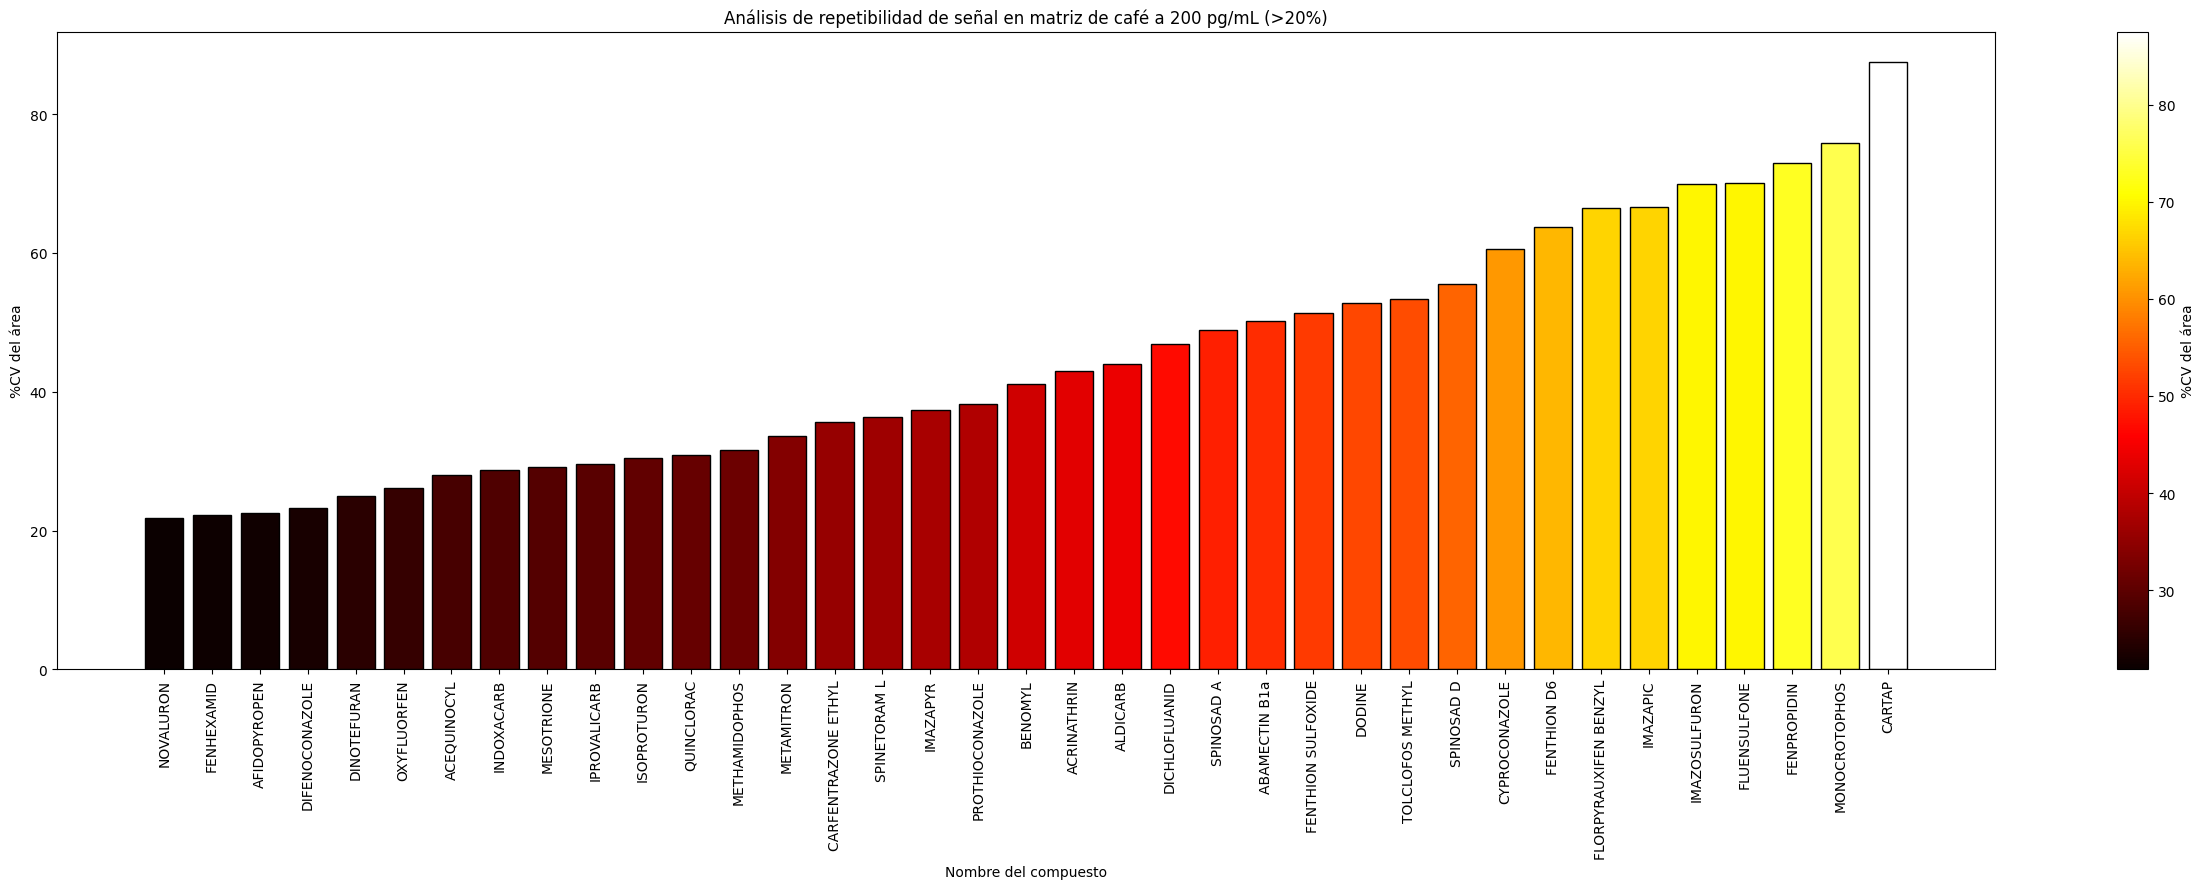

In [33]:
import matplotlib.pyplot as plt

# Filtrar por Component Type = Quantifiers y Area_%CV > 20
resumen_stat_final_high_cv = resumen_stat_final[
    (resumen_stat_final["Component Type"] == "Quantifiers") &
    (resumen_stat_final["Area_%CV"] > 20)
]

# Ordenar por Area_%CV de menor a mayor
resumen_stat_final_high_cv_sorted = resumen_stat_final_high_cv.sort_values(by="Area_%CV", ascending=True)

# Normalizar los valores de %CV para asignar colores según su magnitud
norm = plt.Normalize(
    resumen_stat_final_high_cv_sorted["Area_%CV"].min(),
    resumen_stat_final_high_cv_sorted["Area_%CV"].max()
)
colors = plt.cm.hot(norm(resumen_stat_final_high_cv_sorted["Area_%CV"]))

# Crear gráfico de barras con degradado
plt.figure(figsize=(25, 9))
plt.bar(
    resumen_stat_final_high_cv_sorted["Component Group Name"],
    resumen_stat_final_high_cv_sorted["Area_%CV"],
    color=colors,
    edgecolor='black'
)
plt.xticks(rotation=90)
plt.xlabel("Nombre del compuesto")
plt.ylabel("%CV del área")
plt.title("Análisis de repetibilidad de señal en matriz de café a 200 pg/mL (>20%)")

# Agregar barra de color (colorbar)
sm = plt.cm.ScalarMappable(cmap="hot", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("%CV del área")

plt.tight_layout()
plt.show()
